In [271]:

#Import Libraries
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [272]:
#Read CSV file for Analysis
df = pd.read_csv('samsung_global_sales_dataset.csv')

#Preview Data
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [273]:
#Statistical Data
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,11249.000000
mean,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.743515
std,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.721258
min,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.100000
50%,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.400000
max,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000


In [274]:
#Data Summary/Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [275]:
#Shape of Data
df.shape

(15500, 28)

In [276]:
#Missing/ Incomplete Data
missing_values = df.isnull().sum()
missing_values

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   7849
color                        0
is_5g                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        9373
customer_rating           4251
return_status                0
dtype: int64

In [277]:
#Duplicate Values
df = df.drop_duplicates()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [278]:
#Drop Missing Values
df= df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4474 entries, 2 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 4474 non-null   object 
 1   sale_date               4474 non-null   object 
 2   year                    4474 non-null   int64  
 3   quarter                 4474 non-null   object 
 4   month                   4474 non-null   object 
 5   country                 4474 non-null   object 
 6   region                  4474 non-null   object 
 7   city                    4474 non-null   object 
 8   product_name            4474 non-null   object 
 9   category                4474 non-null   object 
 10  storage                 4474 non-null   object 
 11  color                   4474 non-null   object 
 12  is_5g                   4474 non-null   object 
 13  unit_price_usd          4474 non-null   float64
 14  discount_pct            4474 non-null   int6

In [279]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4474.000000,4.474000e+03,4474.000000
mean,2022.518999,666.779303,5.723514,2.398972,628.202716,1498.695338,941.287211,1.399948e+06,3.741149
std,1.110373,462.568978,6.395158,1.919393,438.485983,1773.905266,3783.599528,8.653096e+06,0.720697
min,2021.000000,90.110000,0.000000,1.000000,72.800000,72.800000,0.790000,7.340000e+01,2.500000
25%,2022.000000,249.957500,0.000000,1.000000,238.392500,409.502500,1.340000,1.563065e+03,3.100000
50%,2023.000000,615.890000,3.000000,2.000000,568.595000,907.540000,10.550000,9.829680e+03,3.700000
75%,2024.000000,966.922500,10.000000,3.000000,920.542500,1845.800000,91.500000,1.011609e+05,4.400000
max,2024.000000,1960.410000,20.000000,10.000000,1958.360000,15818.760000,24500.000000,1.787162e+08,5.000000


In [280]:
df.shape

(4474, 28)

In [281]:
#Business Problem and Questions to ask

#How can the company increase smartphone sales and revenue across regions, products, and customer segments?

#This dataset can help the business understand:

#Which products sell the most
#Which regions generate the most revenue
#Which customer segments buy more
#Whether discounts increase sales
#Which sales channels perform best
#Whether returns or low ratings affect revenue

In [282]:
df['Total Sales'] = df['units_sold'] * df['unit_price_usd']

In [283]:
df['revenue_usd']

2        2165.82
4        3125.96
9        1287.90
13        556.19
14        160.80
          ...   
15481     730.70
15483     369.97
15490     822.65
15495     476.87
15499    1418.25
Name: revenue_usd, Length: 4474, dtype: float64

In [284]:
#Total Revenue
total_revenue = df['revenue_usd'].sum()
total_revenue

np.float64(6705162.9399999995)

In [285]:
#Total Quantity Sold
total_quantity_sold = df['units_sold'].sum()
total_quantity_sold

np.int64(10733)

In [286]:
#Revenue by Product Name
revenue_by_product_name=df.groupby('product_name')['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_product_name

product_name
Samsung Galaxy Z Fold 5     704723.09
Samsung Galaxy Z Fold 4     608029.48
Samsung Galaxy S23 Ultra    451850.31
Samsung Galaxy S22 Ultra    410508.91
Samsung Galaxy S24 Ultra    385612.55
Samsung Galaxy S23+         357379.89
Samsung Galaxy S23          324881.81
Samsung Galaxy S24+         322263.26
Samsung Galaxy S22+         305161.74
Samsung Galaxy Z Flip 5     304656.88
Samsung Galaxy Z Flip 4     294113.90
Samsung Galaxy S24          262839.00
Samsung Galaxy S22          241380.01
Samsung Galaxy Z Flip 3     227620.38
Samsung Galaxy S23 FE       211044.04
Samsung Galaxy A34 5G       161048.86
Samsung Galaxy A53 5G       133388.64
Samsung Galaxy M54 5G       126907.43
Samsung Galaxy S21 FE       125595.56
Samsung Galaxy A54 5G       125469.53
Samsung Galaxy A33 5G       115940.36
Samsung Galaxy A24           97913.05
Samsung Galaxy M34 5G        86735.69
Samsung Galaxy A14 5G        66354.39
Samsung Galaxy A14           62714.39
Samsung Galaxy M14 5G        59846.98

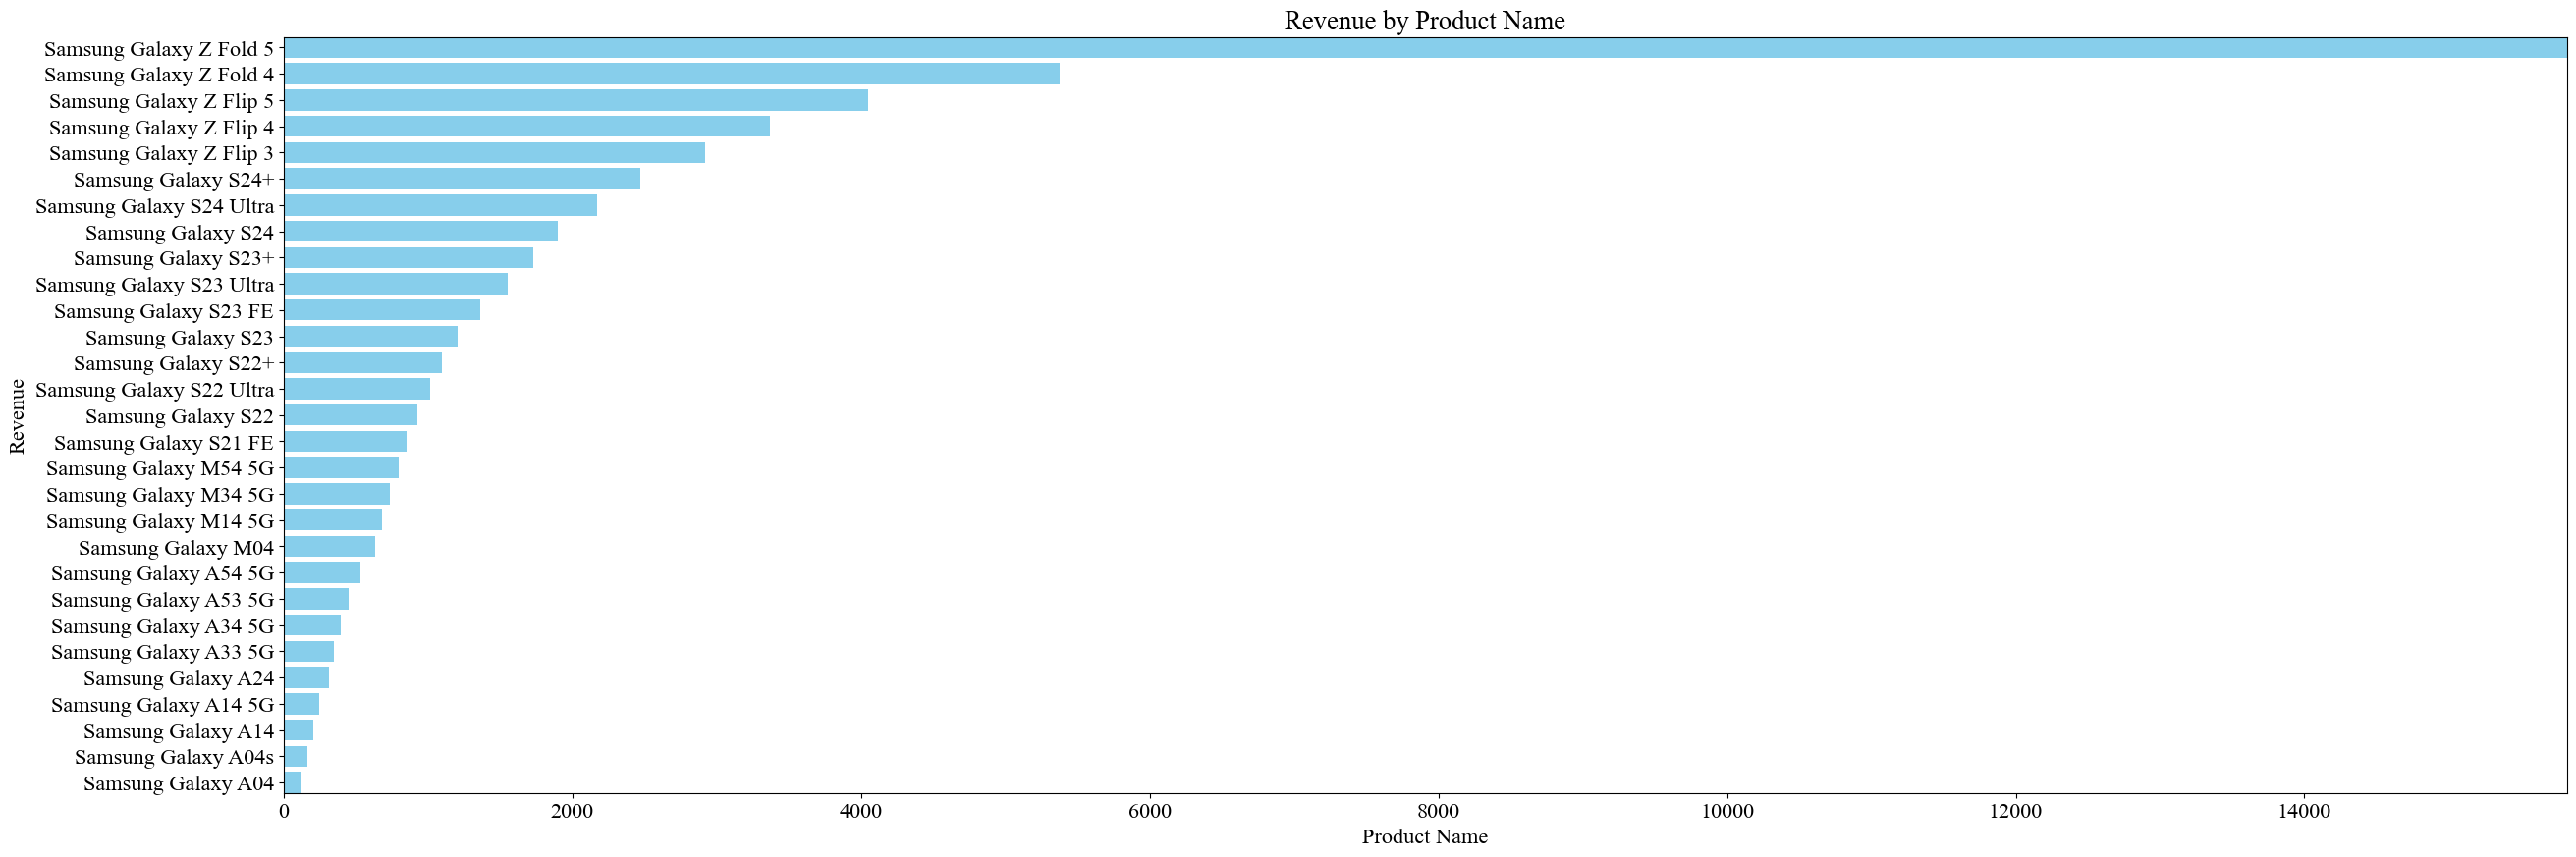

In [287]:
#Sorting Columns
df_sorted_revenue=df.sort_values(by=['revenue_usd'], ascending=True)
df_sorted_product_name=df.sort_values(by=['product_name'], ascending=True)

 #Horizontal Bar Chart
plt.barh(df_sorted_product_name['product_name'],df_sorted_revenue['revenue_usd'], color = 'skyblue')
plt.title('Revenue by Product Name')
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.autoscale(tight=True)
plt.show()

#Font Style
plt.rcParams['font.sans-serif']=['Tahoma']
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size']= 16
plt.rcParams['font.weight']='medium'


In [289]:
#Revenue by Region
revenue_by_region=df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_region


region
Europe           2394754.07
Asia             1903562.79
South America     591524.04
Africa            585170.40
North America     401026.93
Oceania           297106.48
Middle East       275150.68
Europe/Asia       256867.55
Name: revenue_usd, dtype: float64

In [290]:
#Visualizing Revenue by Region on a Map
import plotly.io as pio
pio.renderers.default='browser'
fig=px.choropleth(df,
                  locations='region',
                  locationmode='ISO-3',
                  color='revenue_usd',
                  hover_data=['revenue_usd'],
                  projection='natural earth',
                  color_continuous_scale=px.colors.sequential.Plasma)
#merged=world.merge(left_on='region', right_on='region', how='inner')
#world['region'].plot(column= 'region',cmap='tab10', legend= True, figsize= (10,6), edgecolor='black')
#plt.title('Revenue by Region')
#plt.xlabel('Region')
#plt.ylabel('Revenue')
#plt.autoscale(tight=True)
#merged.plot(column='region', legend=True, cmap='OrRd', figsize = (15,10))
#plt.title('Revenue by Region')
fig.show()

#Fonts
#plt.rcParams['font.sans-serif']=['Tahoma']
#plt.rcParams['axes.unicode_minus']=False
#plt.rcParams['font.size']= 16
#plt.rcParams['font.weight']='medium'


In [291]:
#Revenue by Region and Product Name
revenue_by_region_and_product_name=df.groupby(['region','product_name'])['revenue_usd'].sum().sort_values(ascending=False)
revenue_by_region_and_product_name

region       product_name            
Europe       Samsung Galaxy Z Fold 5     272217.68
             Samsung Galaxy Z Fold 4     237901.95
Asia         Samsung Galaxy Z Fold 4     183180.90
             Samsung Galaxy S23 Ultra    151690.94
Europe       Samsung Galaxy S22 Ultra    149897.38
                                           ...    
Oceania      Samsung Galaxy M34 5G          838.24
             Samsung Galaxy A04             737.36
Middle East  Samsung Galaxy A53 5G          719.98
Oceania      Samsung Galaxy M04             554.95
Middle East  Samsung Galaxy A54 5G          361.47
Name: revenue_usd, Length: 232, dtype: float64

In [293]:
#Revenue by Category
df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)

category
Galaxy S    3398517.08
Galaxy Z    2139143.73
Galaxy A     851584.25
Galaxy M     315917.88
Name: revenue_usd, dtype: float64

In [294]:
#Revenue by Product Name and Category
df.groupby(['category', 'product_name'])['revenue_usd'].sum().sort_values(ascending=False)

category  product_name            
Galaxy Z  Samsung Galaxy Z Fold 5     704723.09
          Samsung Galaxy Z Fold 4     608029.48
Galaxy S  Samsung Galaxy S23 Ultra    451850.31
          Samsung Galaxy S22 Ultra    410508.91
          Samsung Galaxy S24 Ultra    385612.55
          Samsung Galaxy S23+         357379.89
          Samsung Galaxy S23          324881.81
          Samsung Galaxy S24+         322263.26
          Samsung Galaxy S22+         305161.74
Galaxy Z  Samsung Galaxy Z Flip 5     304656.88
          Samsung Galaxy Z Flip 4     294113.90
Galaxy S  Samsung Galaxy S24          262839.00
          Samsung Galaxy S22          241380.01
Galaxy Z  Samsung Galaxy Z Flip 3     227620.38
Galaxy S  Samsung Galaxy S23 FE       211044.04
Galaxy A  Samsung Galaxy A34 5G       161048.86
          Samsung Galaxy A53 5G       133388.64
Galaxy M  Samsung Galaxy M54 5G       126907.43
Galaxy S  Samsung Galaxy S21 FE       125595.56
Galaxy A  Samsung Galaxy A54 5G       125469.53
     

In [295]:
#Revenue by City
df.groupby('city')['revenue_usd'].sum().sort_values(ascending=False)

city
Singapore         87301.76
Olomouc           53048.55
Ras Al Khaimah    43850.31
Shah Alam         42211.66
Toulouse          36255.32
                    ...   
Delhi              1057.14
Bhopal              922.74
Jeddah              827.18
Leicester           545.48
Mumbai              411.85
Name: revenue_usd, Length: 554, dtype: float64

In [296]:
#Revenue by Sales Channel
df.groupby('sales_channel')['revenue_usd'].sum().sort_values(ascending=False)

sales_channel
E-commerce Platform     996861.07
Samsung Store           992358.59
Carrier Store           984173.63
Third-Party Retailer    949242.11
Online (Samsung.com)    928396.14
Corporate / B2B         927870.40
Authorized Reseller     926261.00
Name: revenue_usd, dtype: float64

In [297]:
#Revenue by Month/Monthly Trend
df.groupby(['month'])['revenue_usd'].sum().sort_values(ascending=False)

month
August       626288.02
January      601439.73
March        596214.87
October      596120.34
June         577654.31
February     563512.95
September    561184.34
April        546989.09
December     535883.27
May          518728.98
July         502952.83
November     478194.21
Name: revenue_usd, dtype: float64

In [298]:
#Revenue by Year
df.groupby(['year'])['revenue_usd'].sum().sort_values(ascending=False)

year
2024    1720641.76
2022    1712246.12
2023    1672965.77
2021    1599309.29
Name: revenue_usd, dtype: float64

In [299]:
#Revenue by Quarter
df.groupby('quarter')['revenue_usd'].sum().sort_values(ascending=False)

quarter
Q1    1761167.55
Q3    1690425.19
Q2    1643372.38
Q4    1610197.82
Name: revenue_usd, dtype: float64

In [306]:
#Revenue by Category and Units Sold(Quantity)
df.groupby('category')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False)

,units_sold,revenue_usd
category,,
Galaxy S,3981,3398517.08
Galaxy Z,1845,2139143.73
Galaxy A,3339,851584.25
Galaxy M,1568,315917.88


In [317]:
#Revenue by Product Name and Units Sold(Quantity)
df.groupby('product_name')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False)

,units_sold,revenue_usd
product_name,,
Samsung Galaxy Z Fold 5,419,704723.09
Samsung Galaxy Z Fold 4,391,608029.48
Samsung Galaxy S23 Ultra,398,451850.31
Samsung Galaxy S22 Ultra,396,410508.91
Samsung Galaxy S24 Ultra,316,385612.55
Samsung Galaxy S23+,380,357379.89
Samsung Galaxy S23,435,324881.81
Samsung Galaxy S24+,343,322263.26
Samsung Galaxy S22+,356,305161.74


In [318]:
#Revenue for Discounts and Units Sold(Quantity)
df.groupby('discount_pct')[['units_sold','revenue_usd']].sum().sort_values(by= 'revenue_usd', ascending=False)

,units_sold,revenue_usd
discount_pct,,
0,4130,2668036.20
5,840,539927.86
3,786,532715.45
15,938,531759.83
2,797,530747.30
7,878,520009.14
12,793,499256.91
10,811,462418.48
20,760,420291.77


In [319]:
#Revenue for Sales Channel
df.groupby('sales_channel')['revenue_usd'].sum().sort_values( ascending=False)

sales_channel
E-commerce Platform     996861.07
Samsung Store           992358.59
Carrier Store           984173.63
Third-Party Retailer    949242.11
Online (Samsung.com)    928396.14
Corporate / B2B         927870.40
Authorized Reseller     926261.00
Name: revenue_usd, dtype: float64

In [320]:
#Revenue by Customer Segment
df.groupby('customer_segment')['revenue_usd'].sum().sort_values(ascending=False)

customer_segment
Individual    1506211.51
Education     1416254.21
Business      1346377.79
Enterprise    1245388.30
Government    1190931.13
Name: revenue_usd, dtype: float64

In [321]:
#Revenue by Customer Age Group, Units Sold and Product Name
df.groupby('customer_age_group')[['revenue_usd','units_sold','product_name']].sum().sort_values(by= 'units_sold', ascending=False)

,revenue_usd,units_sold,product_name
customer_age_group,,,
25–34,1423271.28,2293,Samsung Galaxy A34 5GSamsung Galaxy A53 5GSams...
18–24,1378757.01,2243,Samsung Galaxy M14 5GSamsung Galaxy S21 FESams...
45–54,1367657.91,2144,Samsung Galaxy Z Flip 3Samsung Galaxy A14Samsu...
55+,1286039.48,2048,Samsung Galaxy Z Fold 4Samsung Galaxy M14 5GSa...
35–44,1249437.26,2005,Samsung Galaxy S23 FESamsung Galaxy S23Samsung...


In [322]:
#Revenue by Product Name and Customer Rating
df.groupby('product_name')['customer_rating'].mean().sort_values(ascending=False)

product_name
Samsung Galaxy A04          3.873333
Samsung Galaxy M14 5G       3.863158
Samsung Galaxy S23 FE       3.859259
Samsung Galaxy M34 5G       3.805479
Samsung Galaxy S23          3.786709
Samsung Galaxy S21 FE       3.783333
Samsung Galaxy A54 5G       3.782432
Samsung Galaxy M04          3.780899
Samsung Galaxy S24+         3.769536
Samsung Galaxy A34 5G       3.753012
Samsung Galaxy Z Flip 3     3.751634
Samsung Galaxy A33 5G       3.744755
Samsung Galaxy A53 5G       3.744444
Samsung Galaxy A24          3.743949
Samsung Galaxy A04s         3.735762
Samsung Galaxy Z Flip 5     3.732414
Samsung Galaxy S23+         3.724183
Samsung Galaxy S24 Ultra    3.723288
Samsung Galaxy Z Fold 5     3.714773
Samsung Galaxy S22          3.711250
Samsung Galaxy S24          3.710959
Samsung Galaxy S22+         3.708904
Samsung Galaxy S22 Ultra    3.700000
Samsung Galaxy S23 Ultra    3.691477
Samsung Galaxy A14 5G       3.684138
Samsung Galaxy A14          3.681143
Samsung Galaxy Z Flip 4  

In [323]:
#Return Status by Product Name
df.groupby('product_name')['return_status'].value_counts()

product_name             return_status
Samsung Galaxy A04       Kept             126
                         Returned          14
                         Exchanged         10
Samsung Galaxy A04s      Kept             132
                         Returned          13
                                         ... 
Samsung Galaxy Z Fold 4  Returned          17
                         Exchanged          8
Samsung Galaxy Z Fold 5  Kept             152
                         Returned          16
                         Exchanged          8
Name: count, Length: 87, dtype: int64

In [324]:
df.to_csv('Retail Sales Forecasting-Samsung-Cleaned.csv', index=False)